# OCDS Mapped Data — Basic EDA
**File:** `ocds_mapped_data_fiscal_year_2016_2022_v3.xlsx`  
**Fiscal years:** 2016–2022  
**Goal:** Workability check — shape, dtypes, missing values, distributions, outliers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3f55',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#c9d1d9',
    'ytick.color':      '#c9d1d9',
    'text.color':       '#e6edf3',
    'grid.color':       '#2d3144',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

ACCENT  = '#7c6af7'   # purple
ACCENT2 = '#4fc3f7'   # cyan
WARN    = '#ff6b6b'   # red

FPATH = 'ocds_mapped_data_fiscal_year_2016_2022_v3.xlsx'
print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Sheet inventory

In [2]:
xf = pd.ExcelFile(FPATH)
sheets = xf.sheet_names
print(f'{len(sheets)} sheets found:')
for i, s in enumerate(sheets, 1):
    tmp = xf.parse(s, nrows=0)
    print(f'  {i:2d}. {s:<50s}  ({len(tmp.columns)} cols)')

14 sheets found:
   1. main                                                (36 cols)
   2. parties                                             (6 cols)
   3. tender_items                                        (4 cols)
   4. tender_items_deliveryAddresses                      (5 cols)
   5. tender_participationFees                            (6 cols)
   6. tender_milestones                                   (6 cols)
   7. tender_amendments                                   (5 cols)
   8. tender_identifiers                                  (4 cols)
   9. bids_details                                        (5 cols)
  10. bids_details_tenderers                              (5 cols)
  11. te_it_additionalClassifications                     (4 cols)
  12. awards                                              (7 cols)
  13. awards_suppliers                                    (5 cols)
  14. statistics                                          (6 cols)


## 2 · Load main sheet

In [3]:
df = xf.parse('main')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Shape: 21,424 rows × 36 columns


,_link,ocid,id,date,tag,initiationType,buyer_name,buyer_id,tender_id,tender_title,...,tender_communication_documentAvailabilityPeriod_endDate,tender_bidOpening_date,tender_bidOpening_address_streetAddress,tender_submissionTerms_allowPreferentialBidder,tender_submissionTerms_allowMultiCurrencyFee,tender_submissionTerms_allowMultiCurrencyBQQ,tender_submissionTerms_bidValidityPeriod_durationInDays,tender_enquiryPeriod_startDate,tender_enquiryPeriod_endDate,tender_enquiryPeriod_durationInDays
0,0,ocds-f5kvwu-2017_NHM_2075_1,1,2023-12-18T00:00:00Z,tender,tender,National Health Mission,nationalhealthmission,2017_NHM_2075_1,Upgradation of existing Bokakhat SDCH in Golag...,...,2017-04-20T14:00:00Z,2017-04-21T15:30:00Z,Office of the Mission Director NHM Assam,No,No,No,180,NaN,NaN,NaN
1,1,ocds-f5kvwu-2017_NHM_2147_1,1,2023-12-18T00:00:00Z,tender,tender,National Health Mission,nationalhealthmission,2017_NHM_2147_1,Upgradation of existing Jonai BPHC to SDCH in ...,...,2017-05-29T14:00:00Z,2017-05-30T15:30:00Z,Office of the Mission Director NHM Assam,No,No,No,180,NaN,NaN,NaN
2,2,ocds-f5kvwu-2017_NHM_2506_1,1,2023-12-18T00:00:00Z,tender,tender,National Health Mission,nationalhealthmission,2017_NHM_2506_1,EMERGENCY RESPONSE SERVICES popularly known as...,...,2017-08-29T14:00:00Z,2017-08-29T15:00:00Z,"Office of the Mission Director, National Healt...",No,No,No,180,NaN,NaN,NaN


## 3 · Column dtypes

In [4]:
dtype_summary = df.dtypes.reset_index()
dtype_summary.columns = ['column', 'dtype']
dtype_summary['dtype'] = dtype_summary['dtype'].astype(str)
print(dtype_summary.to_string(index=False))

                                                   column   dtype
                                                    _link   int64
                                                     ocid  object
                                                       id   int64
                                                     date  object
                                                      tag  object
                                           initiationType  object
                                               buyer_name  object
                                                 buyer_id  object
                                                tender_id  object
                                             tender_title  object
                                       tender_description  object
                                     tender_datePublished  object
                                      tender_contractType  object
                                 tender_numberOfTenderers float64
          

## 4 · Missing value analysis

In [5]:
n = len(df)
miss = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct':   df.isnull().mean().mul(100).round(2)
}).sort_values('missing_pct', ascending=False)

miss['completeness_pct'] = (100 - miss['missing_pct']).round(2)
display(miss)

,missing_count,missing_pct,completeness_pct
tender_enquiryPeriod_durationInDays,13614,63.55,36.45
tender_enquiryPeriod_endDate,13614,63.55,36.45
tender_enquiryPeriod_startDate,13614,63.55,36.45
tender_numberOfTenderers,7232,33.76,66.24
tender_value_amount,4109,19.18,80.82
tender_value_currency,4109,19.18,80.82
tender_contractPeriod_durationInDays,1207,5.63,94.37
tender_submissionTerms_allowMultiCurrencyFee,0,0.00,100.00
tender_submissionTerms_allowPreferentialBidder,0,0.00,100.00
tender_bidOpening_address_streetAddress,0,0.00,100.00


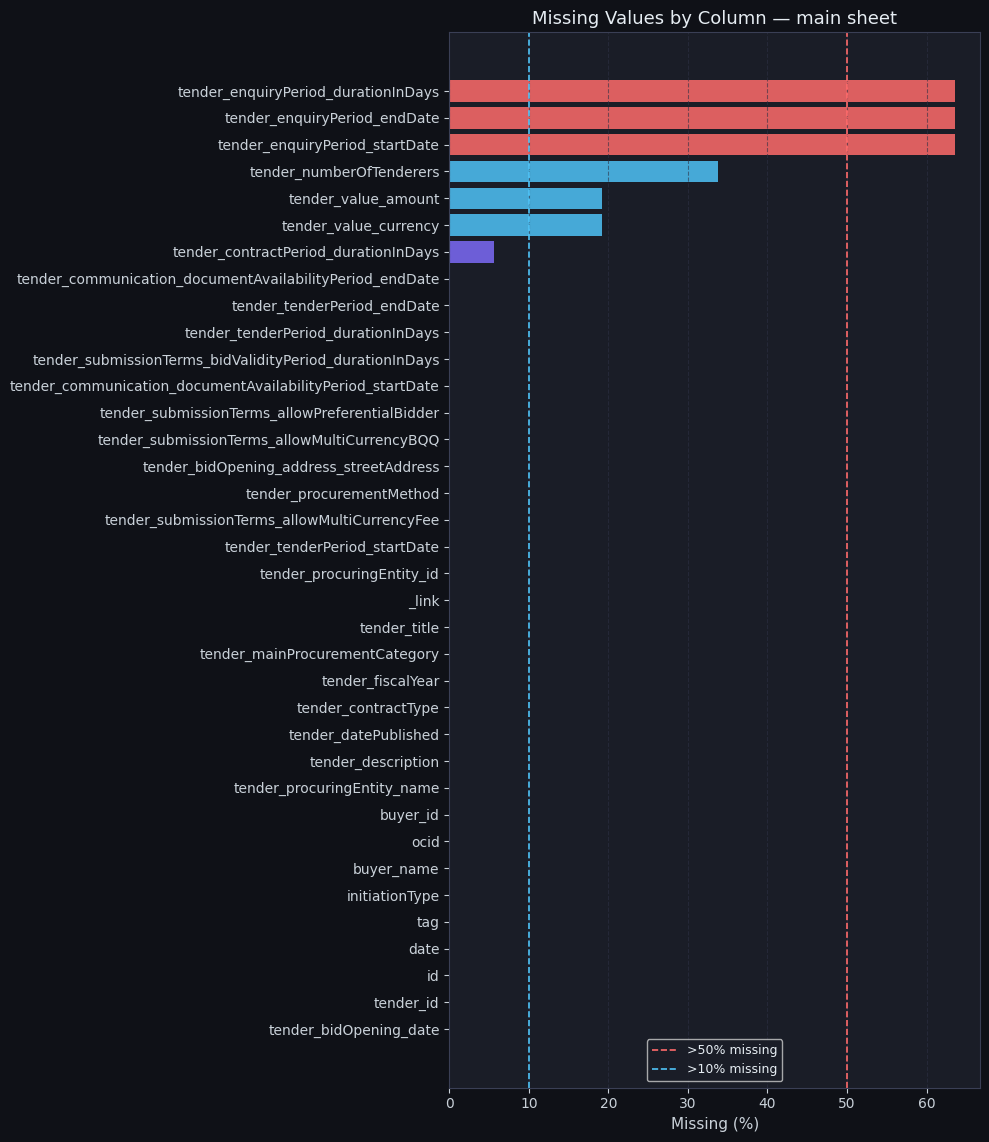

In [6]:
# Visual: missing % per column
miss_sorted = miss.sort_values('missing_pct')
colors = [WARN if v > 50 else ACCENT2 if v > 10 else ACCENT
          for v in miss_sorted['missing_pct']]

fig, ax = plt.subplots(figsize=(10, max(6, len(miss_sorted)*0.32)))
bars = ax.barh(miss_sorted.index, miss_sorted['missing_pct'], color=colors, alpha=0.85, edgecolor='none')
ax.axvline(50, color=WARN,    lw=1.2, ls='--', label='>50% missing')
ax.axvline(10, color=ACCENT2, lw=1.2, ls='--', label='>10% missing')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column — main sheet')
ax.legend(fontsize=9)
ax.grid(axis='x')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Descriptive statistics — numeric columns

In [7]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Numeric columns ({len(num_cols)}): {num_cols}')
display(df[num_cols].describe().T.style.background_gradient(cmap='Blues'))

Numeric columns (8): ['_link', 'id', 'tender_numberOfTenderers', 'tender_value_amount', 'tender_tenderPeriod_durationInDays', 'tender_contractPeriod_durationInDays', 'tender_submissionTerms_bidValidityPeriod_durationInDays', 'tender_enquiryPeriod_durationInDays']


,count,mean,std,min,25%,50%,75%,max
_link,21424.000000,10711.500000,6184.720419,0.000000,5355.750000,10711.500000,16067.250000,21423.000000
id,21424.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
tender_numberOfTenderers,14192.000000,6.336598,25.808042,2.000000,4.000000,5.000000,6.000000,1380.000000
tender_value_amount,17315.000000,58118912.019521,371330875.554081,0.000000,4908523.000000,9765000.000000,23197101.000000,20000000000.000000
tender_tenderPeriod_durationInDays,21424.000000,17.402539,19.928595,-1453.000000,9.000000,15.000000,21.000000,334.000000
tender_contractPeriod_durationInDays,20217.000000,265.035020,376.714894,0.000000,90.000000,180.000000,365.000000,21900.000000
tender_submissionTerms_bidValidityPeriod_durationInDays,21424.000000,170.977689,84.434341,1.000000,120.000000,180.000000,180.000000,999.000000
tender_enquiryPeriod_durationInDays,7810.000000,10.597567,6.548108,0.000000,6.000000,9.000000,14.000000,72.000000


## 6 · Fiscal year distribution

tender_fiscalYear
2016-2017      43
2017-2018     430
2018-2019    1301
2019-2020    1919
2020-2021    4367
2021-2022    5121
2022-2023    8241
2023-2024       2
Name: count, dtype: int64


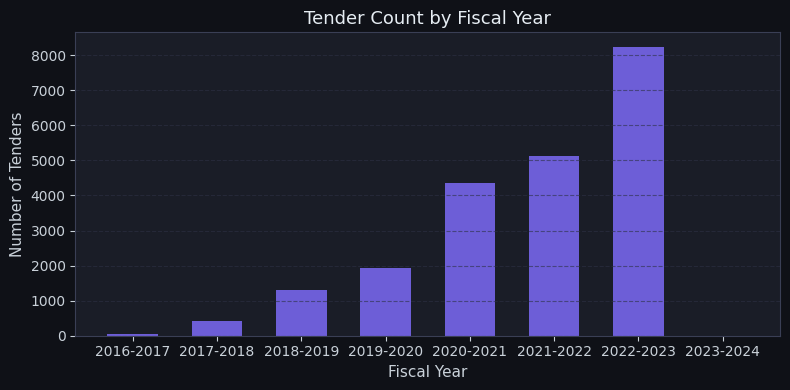

In [8]:
if 'tender_fiscalYear' in df.columns:
    fy_counts = df['tender_fiscalYear'].value_counts().sort_index()
    print(fy_counts)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(fy_counts.index.astype(str), fy_counts.values, color=ACCENT, alpha=0.85, edgecolor='none', width=0.6)
    ax.set_xlabel('Fiscal Year')
    ax.set_ylabel('Number of Tenders')
    ax.set_title('Tender Count by Fiscal Year')
    ax.grid(axis='y')
    plt.tight_layout()
    plt.savefig('fiscal_year_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Column tender_fiscalYear not found')

## 7 · Tender value distribution

Non-null tender values: 17,315 / 21,424
Min : 0.00
Max : 20,000,000,000.00
Mean: 58,118,912.02
Med : 9,765,000.00
Std : 371,330,875.55


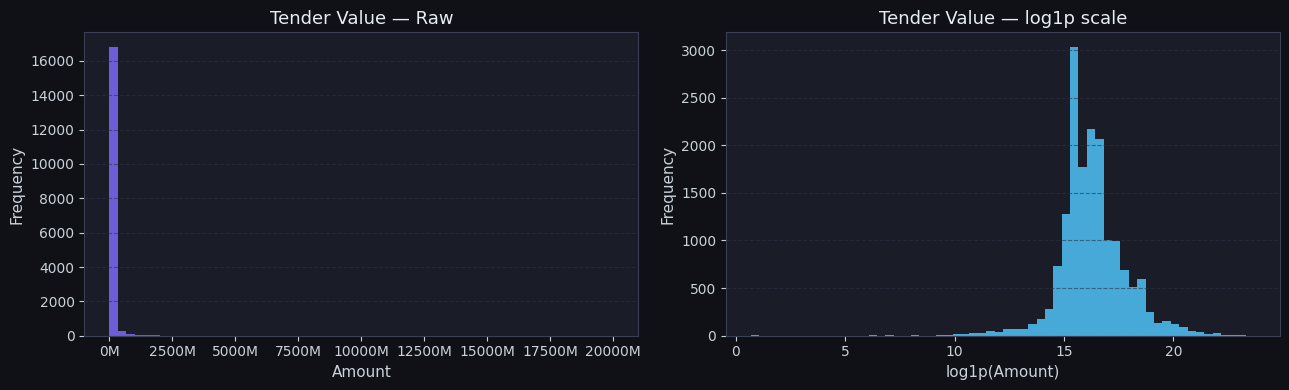

In [9]:
if 'tender_value_amount' in df.columns:
    tv = df['tender_value_amount'].dropna()
    print(f'Non-null tender values: {len(tv):,} / {len(df):,}')
    print(f'Min : {tv.min():,.2f}')
    print(f'Max : {tv.max():,.2f}')
    print(f'Mean: {tv.mean():,.2f}')
    print(f'Med : {tv.median():,.2f}')
    print(f'Std : {tv.std():,.2f}')

    tv_log = np.log1p(tv[tv > 0])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(tv, bins=60, color=ACCENT, alpha=0.85, edgecolor='none')
    axes[0].set_title('Tender Value — Raw')
    axes[0].set_xlabel('Amount')
    axes[0].set_ylabel('Frequency')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    axes[0].grid(axis='y')

    axes[1].hist(tv_log, bins=60, color=ACCENT2, alpha=0.85, edgecolor='none')
    axes[1].set_title('Tender Value — log1p scale')
    axes[1].set_xlabel('log1p(Amount)')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(axis='y')

    plt.tight_layout()
    plt.savefig('tender_value_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Column tender_value_amount not found')

## 8 · Categorical column cardinalities

In [10]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Object/string columns ({len(cat_cols)})')
card = pd.DataFrame({
    'unique_values': [df[c].nunique() for c in cat_cols],
    'top_value':     [df[c].mode().iloc[0] if df[c].notna().any() else None for c in cat_cols],
    'top_freq':      [df[c].value_counts().iloc[0] if df[c].notna().any() else None for c in cat_cols],
    'top_freq_pct':  [(df[c].value_counts().iloc[0]/len(df)*100).round(1) if df[c].notna().any() else None for c in cat_cols],
}, index=cat_cols)
display(card.sort_values('unique_values', ascending=False))

Object/string columns (28)


,unique_values,top_value,top_freq,top_freq_pct
ocid,21424,ocds-f5kvwu-2017_NHM_2075_1,1,0.0
tender_id,21424,2017_NHM_2075_1,1,0.0
tender_title,19142,"DIFFERENT WORKS OF EXTENSION, RENOVATION AND M...",66,0.3
tender_description,18526,Improvement of Various works under 2nd Install...,160,0.7
tender_communication_documentAvailabilityPeriod_startDate,7914,2022-12-05T09:55:00Z,125,0.6
tender_tenderPeriod_startDate,7694,2022-12-05T09:55:00Z,125,0.6
tender_datePublished,7694,2022-12-05T09:55:00Z,125,0.6
tender_bidOpening_date,5560,2022-12-23T14:30:00Z,336,1.6
tender_tenderPeriod_endDate,4184,2022-12-22T14:00:00Z,403,1.9
tender_communication_documentAvailabilityPeriod_endDate,4182,2022-12-22T14:00:00Z,403,1.9


## 9 · Key categorical breakdowns

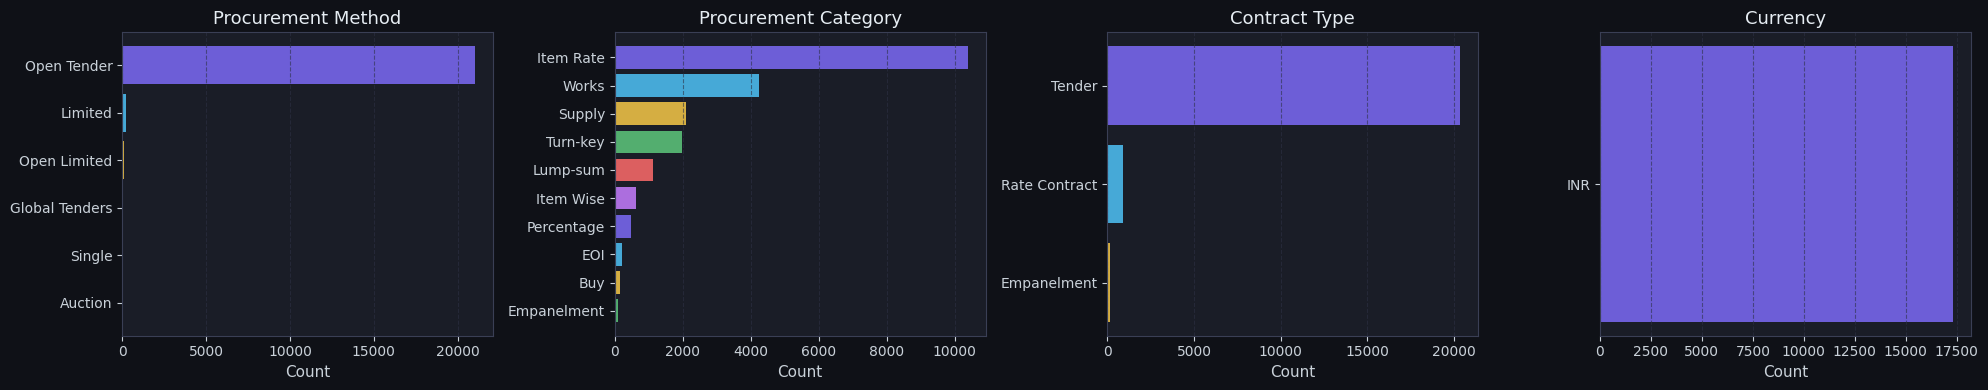

In [11]:
key_cats = [
    ('tender_procurementMethod',      'Procurement Method'),
    ('tender_mainProcurementCategory','Procurement Category'),
    ('tender_contractType',           'Contract Type'),
    ('tender_value_currency',         'Currency'),
]

existing = [(c, l) for c, l in key_cats if c in df.columns]
n_plots  = len(existing)

fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4))
if n_plots == 1:
    axes = [axes]

PALETTE = [ACCENT, ACCENT2, '#f7c948', '#5ec97d', '#ff6b6b', '#c77dff']

for ax, (col, label) in zip(axes, existing):
    vc = df[col].value_counts().head(10)
    colors_bar = [PALETTE[i % len(PALETTE)] for i in range(len(vc))]
    ax.barh(vc.index[::-1], vc.values[::-1], color=colors_bar[::-1], alpha=0.85, edgecolor='none')
    ax.set_title(label)
    ax.set_xlabel('Count')
    ax.grid(axis='x')

plt.tight_layout()
plt.savefig('categorical_breakdowns.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 · Number of tenderers — distribution

Non-null: 14,192
count    14192.000000
mean         6.336598
std         25.808042
min          2.000000
25%          4.000000
50%          5.000000
75%          6.000000
max       1380.000000
Name: tender_numberOfTenderers, dtype: float64


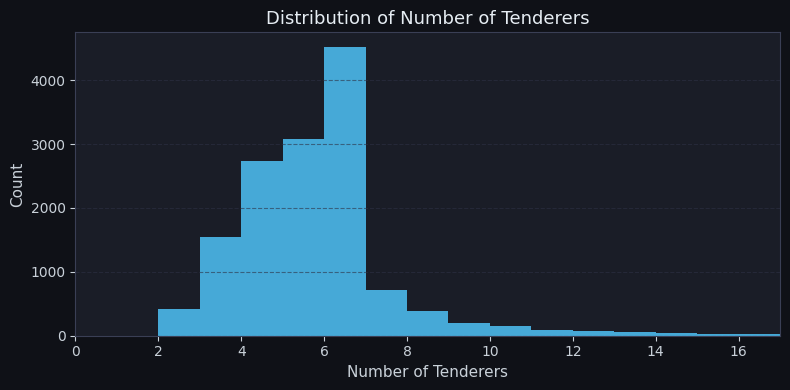

In [12]:
if 'tender_numberOfTenderers' in df.columns:
    nt = df['tender_numberOfTenderers'].dropna()
    print(f'Non-null: {len(nt):,}')
    print(nt.describe())

    fig, ax = plt.subplots(figsize=(8, 4))
    bins = range(0, int(nt.max())+2)
    ax.hist(nt, bins=bins, color=ACCENT2, alpha=0.85, edgecolor='none')
    ax.set_xlabel('Number of Tenderers')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Number of Tenderers')
    ax.set_xlim(0, nt.quantile(0.99)+1)   # clip extreme outliers
    ax.grid(axis='y')
    plt.tight_layout()
    plt.savefig('num_tenderers_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Column tender_numberOfTenderers not found')

## 11 · Tender duration analysis

Duration columns: ['tender_tenderPeriod_durationInDays', 'tender_contractPeriod_durationInDays', 'tender_submissionTerms_bidValidityPeriod_durationInDays', 'tender_enquiryPeriod_durationInDays']


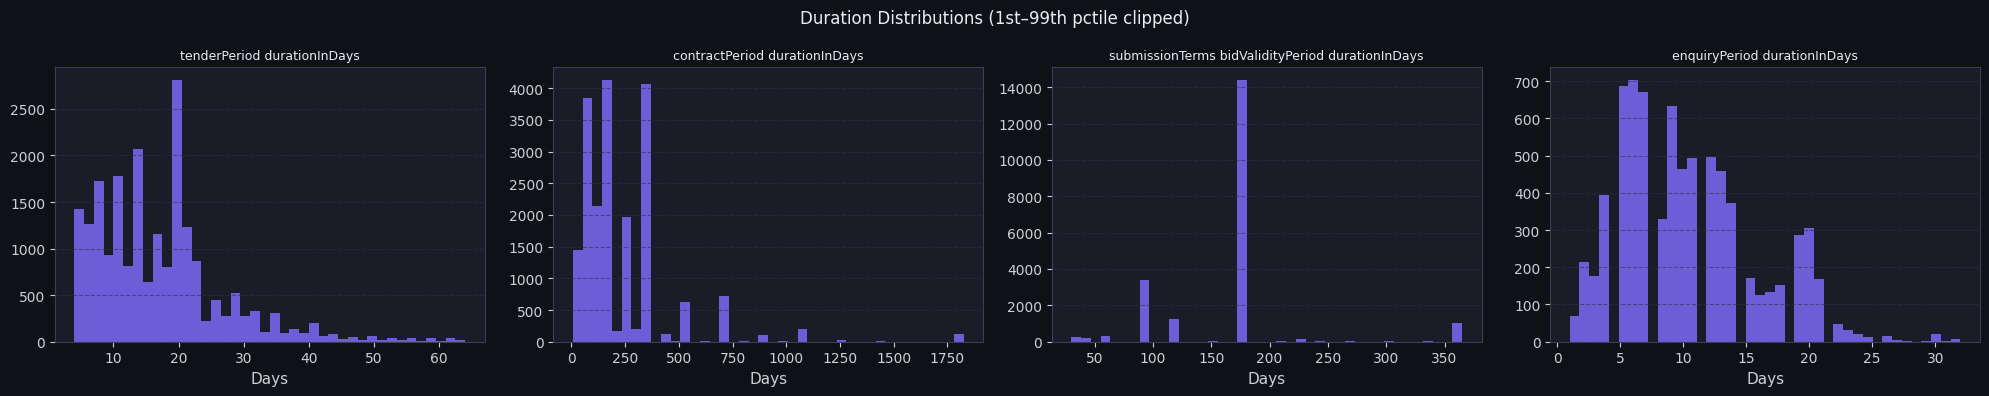

In [13]:
dur_cols = [c for c in df.columns if 'durationInDays' in c or 'Duration' in c]
print('Duration columns:', dur_cols)

if dur_cols:
    fig, axes = plt.subplots(1, len(dur_cols), figsize=(5*len(dur_cols), 4))
    if len(dur_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, dur_cols):
        s = df[col].dropna()
        s_clip = s[s.between(s.quantile(0.01), s.quantile(0.99))]
        ax.hist(s_clip, bins=40, color=ACCENT, alpha=0.85, edgecolor='none')
        ax.set_title(col.replace('tender_','').replace('_',' '), fontsize=9)
        ax.set_xlabel('Days')
        ax.grid(axis='y')
    plt.suptitle('Duration Distributions (1st–99th pctile clipped)', fontsize=12)
    plt.tight_layout()
    plt.savefig('duration_dists.png', dpi=150, bbox_inches='tight')
    plt.show()

## 12 · Duplicate check

In [14]:
dups_ocid = df['ocid'].duplicated().sum() if 'ocid' in df.columns else 'N/A'
dups_full = df.duplicated().sum()

print(f'Duplicate OCIDs      : {dups_ocid}')
print(f'Fully duplicate rows : {dups_full}')

Duplicate OCIDs      : 0
Fully duplicate rows : 0


## 13 · Date fields — coverage & range

In [15]:
date_cols = [c for c in df.columns if 'Date' in c or 'date' in c]
print('Date-like columns:', date_cols)

for col in date_cols:
    parsed = pd.to_datetime(df[col], errors='coerce')
    non_null = parsed.notna().sum()
    if non_null > 0:
        print(f'  {col}: {non_null:,} valid  |  {parsed.min().date()} → {parsed.max().date()}')
    else:
        print(f'  {col}: 0 valid (all NaT or unparseable)')

Date-like columns: ['date', 'tender_datePublished', 'tender_tenderPeriod_startDate', 'tender_tenderPeriod_endDate', 'tender_communication_documentAvailabilityPeriod_startDate', 'tender_communication_documentAvailabilityPeriod_endDate', 'tender_bidOpening_date', 'tender_enquiryPeriod_startDate', 'tender_enquiryPeriod_endDate']
  date: 21,424 valid  |  2023-12-18 → 2023-12-18
  tender_datePublished: 21,424 valid  |  2017-01-03 → 2023-05-16
  tender_tenderPeriod_startDate: 21,424 valid  |  2017-01-03 → 2023-05-16
  tender_tenderPeriod_endDate: 21,424 valid  |  2017-02-13 → 2023-05-18
  tender_communication_documentAvailabilityPeriod_startDate: 21,424 valid  |  2017-01-03 → 2023-05-01
  tender_communication_documentAvailabilityPeriod_endDate: 21,424 valid  |  2017-02-13 → 2023-05-18
  tender_bidOpening_date: 21,424 valid  |  2017-02-13 → 2023-05-19
  tender_enquiryPeriod_startDate: 7,810 valid  |  2017-02-21 → 2023-05-02
  tender_enquiryPeriod_endDate: 7,810 valid  |  2017-03-13 → 2023-05-

## 14 · All sheets — quick shape summary

In [16]:
rows = []
for s in sheets:
    tmp = xf.parse(s)
    miss_pct = tmp.isnull().mean().mean() * 100
    rows.append({
        'sheet': s,
        'rows': tmp.shape[0],
        'cols': tmp.shape[1],
        'avg_missing_pct': round(miss_pct, 1)
    })
sheet_summary = pd.DataFrame(rows)
display(sheet_summary.style.background_gradient(subset=['avg_missing_pct'], cmap='Reds'))

,sheet,rows,cols,avg_missing_pct
0,main,21424,36,7.500000
1,parties,111206,6,13.500000
2,tender_items,21424,4,0.000000
3,tender_items_deliveryAddresses,21424,5,0.000000
4,tender_participationFees,21424,6,0.000000
5,tender_milestones,156170,6,0.000000
6,tender_amendments,7839,5,0.800000
7,tender_identifiers,21424,4,0.000000
8,bids_details,68358,5,0.000000
9,bids_details_tenderers,68358,5,0.000000


## 15 · Workability summary

In [17]:
print('='*55)
print(' WORKABILITY SUMMARY')
print('='*55)
print(f'Total records (main sheet) : {len(df):,}')
print(f'Total columns              : {df.shape[1]}')
print(f'Numeric columns            : {len(df.select_dtypes(include="number").columns)}')
print(f'Object/cat columns         : {len(df.select_dtypes(include="object").columns)}')

pct_complete = (1 - df.isnull().mean().mean()) * 100
print(f'Overall completeness       : {pct_complete:.1f}%')

cols_gt80 = (df.isnull().mean() > 0.80).sum()
cols_gt50 = (df.isnull().mean() > 0.50).sum()
cols_gt20 = (df.isnull().mean() > 0.20).sum()

print(f'Columns >80% missing       : {cols_gt80}')
print(f'Columns >50% missing       : {cols_gt50}')
print(f'Columns >20% missing       : {cols_gt20}')
print('='*55)

 WORKABILITY SUMMARY
Total records (main sheet) : 21,424
Total columns              : 36
Numeric columns            : 8
Object/cat columns         : 28
Overall completeness       : 92.5%
Columns >80% missing       : 0
Columns >50% missing       : 3
Columns >20% missing       : 4
